<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/DMC_Sabrina_Forecast_Target_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
input_df = pd.read_csv("eingangsbandwaage_studenten.csv")
target_df = pd.read_csv("ballengewichte_studenten.csv")

input_df["Zeitstempel"] = pd.to_datetime(input_df["Zeitstempel"])
target_df["Datum"] = pd.to_datetime(target_df["Datum"])

input_df = input_df.rename(columns={"Zeitstempel": "date"})
target_df = target_df.rename(columns={"Datum": "date"})

df = pd.merge(
    target_df,
    input_df,
    on="date",
    how="inner"
)

df = df.sort_values("date").reset_index(drop=True)

display(df.head())
print(df.shape)

,date,1,2,3,4,5,6,7,8,9,10,11,12,13,14,Masse
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000,0.0,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807,0.0,0.544210


(1546, 16)


In [37]:
min_date = df['date'].min()
max_date = df['date'].max()

print(f"The date range of the dataset is from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}.")

The date range of the dataset is from 2020-03-02 to 2024-12-31.


In [33]:
#target column
target_col = "1"


#Manually select the time based column feature to build random forest
# Clean Masse
df["Masse_clean"] = df["Masse"].clip(lower=0)

# Create lag features
lags = [1, 2, 7, 14]

for lag in lags:
    df[f"Masse_lag_{lag}"] = df["Masse_clean"].shift(lag)
    df[f"target_1_lag_{lag}"] = df[target_col].shift(lag)

# Calendar feature
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Final feature list
feature_cols = [
    "Masse_clean",
    "Masse_lag_1",
    "Masse_lag_2",
    "Masse_lag_7",
    "Masse_lag_14",
    "target_1_lag_1",
    "target_1_lag_2",
    "target_1_lag_7",
    "target_1_lag_14",
    "month_sin",
    "month_cos"
]

model_df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(model_df[["date", target_col] + feature_cols].head())

X shape: (1532, 11)
y shape: (1532,)


,date,1,Masse_clean,Masse_lag_1,Masse_lag_2,Masse_lag_7,Masse_lag_14,target_1_lag_1,target_1_lag_2,target_1_lag_7,target_1_lag_14,month_sin,month_cos
0,2020-03-30,0.254328,0.562966,0.676445,0.681476,0.599744,0.291561,0.135348,0.228954,0.205198,0.000000,1.000000,6.123234e-17
1,2020-03-31,0.121960,0.524558,0.562966,0.676445,0.599833,0.638127,0.254328,0.135348,0.185218,1.000000,1.000000,6.123234e-17
2,2020-04-01,0.204284,0.469459,0.524558,0.562966,0.584717,0.320958,0.121960,0.254328,0.153014,1.000000,0.866025,-5.000000e-01
3,2020-04-02,0.128373,0.410352,0.469459,0.524558,0.517333,0.457763,0.204284,0.121960,0.216507,0.174107,0.866025,-5.000000e-01
4,2020-04-03,0.186749,0.572191,0.410352,0.469459,0.576594,0.544210,0.128373,0.204284,0.150809,0.215771,0.866025,-5.000000e-01


In [34]:
# Defining models
models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),

    "Random Forest CV": RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

# Defining time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

In [35]:
# Running time-series cross-validation
cv_results = []
prediction_parts_cv = []

for model_name, model in models.items():

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # Do not clip unless target values are naturally between 0 and 1
        # y_pred = np.clip(y_pred, 0, 1)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        cv_results.append({
            "model": model_name,
            "fold": fold,
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "MAE": mae,
            "RMSE": rmse
        })

        if model_name == "Random Forest CV":
            fold_prediction = model_df.iloc[test_idx][["date", "Masse", target_col]].copy()
            fold_prediction = fold_prediction.rename(columns={target_col: "real_col_1"})

            fold_prediction["predicted_col_1"] = y_pred
            fold_prediction["error"] = fold_prediction["real_col_1"] - fold_prediction["predicted_col_1"]
            fold_prediction["absolute_error"] = fold_prediction["error"].abs()
            fold_prediction["fold"] = fold

            prediction_parts_cv.append(fold_prediction)

In [38]:
# Creating CV result tables
cv_results_df = pd.DataFrame(cv_results)

summary_cv_results = (
    cv_results_df
    .groupby("model")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
    .sort_values("MAE")
)

real_vs_prediction_cv_df = pd.concat(prediction_parts_cv).reset_index(drop=True)

print("CV fold results")
display(cv_results_df)

print("CV summary results")
display(summary_cv_results)

print("CV real vs predicted")
display(real_vs_prediction_cv_df.head())
display(real_vs_prediction_cv_df.tail())

CV fold results


,model,fold,train_size,test_size,MAE,RMSE
0,Dummy Mean,1,257,255,0.052425,0.076508
1,Dummy Mean,2,512,255,0.024670,0.039744
2,Dummy Mean,3,767,255,0.023781,0.039636
3,Dummy Mean,4,1022,255,0.043084,0.061580
4,Dummy Mean,5,1277,255,0.055736,0.087735
5,Random Forest CV,1,257,255,0.052471,0.080407
6,Random Forest CV,2,512,255,0.025343,0.041105
7,Random Forest CV,3,767,255,0.028354,0.045498
8,Random Forest CV,4,1022,255,0.034194,0.054609
9,Random Forest CV,5,1277,255,0.036381,0.071344


CV summary results


,model,MAE,RMSE
1,Random Forest CV,0.035349,0.058593
0,Dummy Mean,0.039939,0.061041


CV real vs predicted


,date,Masse,real_col_1,predicted_col_1,error,absolute_error,fold
0,2021-01-17,0.054322,0.578123,0.251702,0.326421,0.326421,1
1,2021-01-18,0.674047,0.233372,0.215242,0.018130,0.018130,1
2,2021-01-19,0.683132,0.213751,0.216863,-0.003112,0.003112,1
3,2021-01-20,0.634418,0.180643,0.203704,-0.023060,0.023060,1
4,2021-01-21,0.634000,0.163063,0.191867,-0.028805,0.028805,1


,date,Masse,real_col_1,predicted_col_1,error,absolute_error,fold
1270,2024-12-27,0.893760,0.263026,0.218900,0.044126,0.044126,5
1271,2024-12-28,0.775929,0.239367,0.233278,0.006089,0.006089,5
1272,2024-12-29,0.629213,0.336419,0.231828,0.104591,0.104591,5
1273,2024-12-30,0.862853,0.246167,0.230731,0.015436,0.015436,5
1274,2024-12-31,0.796738,0.258223,0.238947,0.019276,0.019276,5


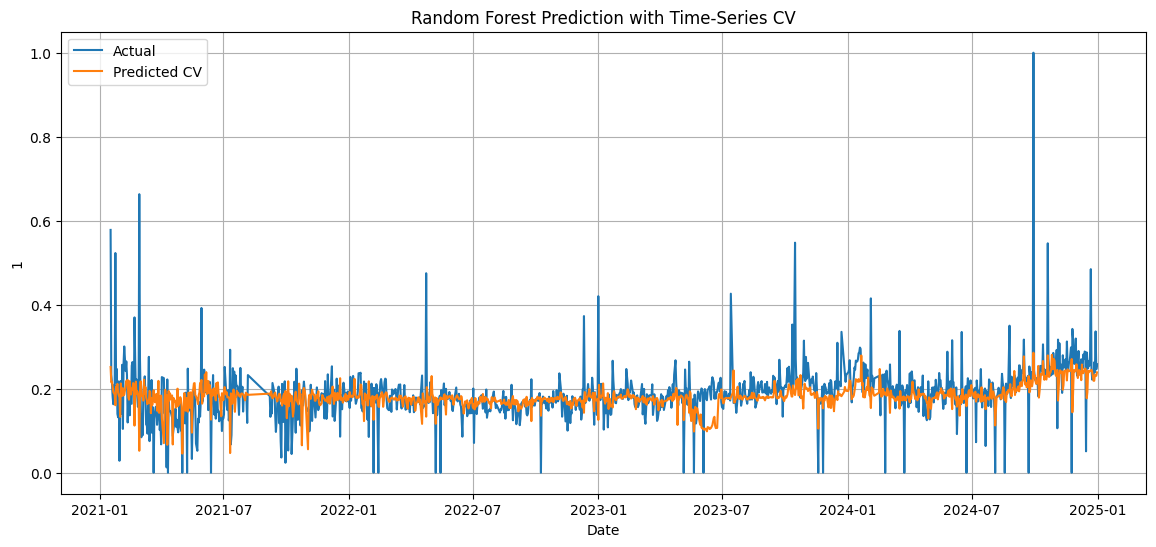

In [25]:
# Plotting CV prediction
plt.figure(figsize=(14, 6))

plt.plot(
    real_vs_prediction_cv_df["date"],
    real_vs_prediction_cv_df["real_col_1"],
    label="Actual"
)

plt.plot(
    real_vs_prediction_cv_df["date"],
    real_vs_prediction_cv_df["predicted_col_1"],
    label="Predicted CV"
)

plt.xlabel("Date")
plt.ylabel(target_col)
plt.title("Random Forest Prediction with Time-Series CV")
plt.legend()
plt.grid(True)
plt.show()

#Without CV


In [26]:
# Creating one fixed train-test split
split_idx = int(len(model_df) * 0.8)

X_train_no_cv = X.iloc[:split_idx]
X_test_no_cv = X.iloc[split_idx:]

y_train_no_cv = y.iloc[:split_idx]
y_test_no_cv = y.iloc[split_idx:]

print("Without CV train period:")
print(model_df["date"].iloc[:split_idx].min(), "to", model_df["date"].iloc[:split_idx].max())

print("\nWithout CV test period:")
print(model_df["date"].iloc[split_idx:].min(), "to", model_df["date"].iloc[split_idx:].max())

print("\nTrain size:", len(X_train_no_cv))
print("Test size:", len(X_test_no_cv))

Without CV train period:
2020-03-30 00:00:00 to 2024-02-18 00:00:00

Without CV test period:
2024-02-19 00:00:00 to 2024-12-31 00:00:00

Train size: 1225
Test size: 307


In [27]:
# Training Random Forest without CV
rf_model_no_cv = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model_no_cv.fit(X_train_no_cv, y_train_no_cv)

y_pred_no_cv = rf_model_no_cv.predict(X_test_no_cv)

# Do not clip unless target values are naturally between 0 and 1
# y_pred_no_cv = np.clip(y_pred_no_cv, 0, 1)

In [28]:
# Calculating without-CV errors
mae_no_cv = mean_absolute_error(y_test_no_cv, y_pred_no_cv)
rmse_no_cv = np.sqrt(mean_squared_error(y_test_no_cv, y_pred_no_cv))

no_cv_result = pd.DataFrame({
    "model": ["Random Forest Without CV"],
    "MAE": [mae_no_cv],
    "RMSE": [rmse_no_cv]
})

display(no_cv_result)

,model,MAE,RMSE
0,Random Forest Without CV,0.036135,0.069438


In [29]:
# Creating real vs predicted table for without-CV result
real_vs_prediction_no_cv_df = model_df.iloc[split_idx:][["date", "Masse", target_col]].copy()

real_vs_prediction_no_cv_df = real_vs_prediction_no_cv_df.rename(
    columns={target_col: "real_col_1"}
)

real_vs_prediction_no_cv_df["predicted_col_1"] = y_pred_no_cv

real_vs_prediction_no_cv_df["error"] = (
    real_vs_prediction_no_cv_df["real_col_1"]
    - real_vs_prediction_no_cv_df["predicted_col_1"]
)

real_vs_prediction_no_cv_df["absolute_error"] = real_vs_prediction_no_cv_df["error"].abs()

display(real_vs_prediction_no_cv_df.head())
display(real_vs_prediction_no_cv_df.tail())

,date,Masse,real_col_1,predicted_col_1,error,absolute_error
1225,2024-02-19,0.640364,0.223037,0.181590,0.041447,0.041447
1226,2024-02-20,0.613932,0.216108,0.182455,0.033654,0.033654
1227,2024-02-21,0.605921,0.233452,0.207433,0.026019,0.026019
1228,2024-02-22,0.544057,0.203260,0.214985,-0.011725,0.011725
1229,2024-02-23,0.549252,0.225972,0.196194,0.029778,0.029778


,date,Masse,real_col_1,predicted_col_1,error,absolute_error
1527,2024-12-27,0.893760,0.263026,0.224186,0.038840,0.038840
1528,2024-12-28,0.775929,0.239367,0.235722,0.003646,0.003646
1529,2024-12-29,0.629213,0.336419,0.235040,0.101380,0.101380
1530,2024-12-30,0.862853,0.246167,0.229477,0.016690,0.016690
1531,2024-12-31,0.796738,0.258223,0.240040,0.018183,0.018183


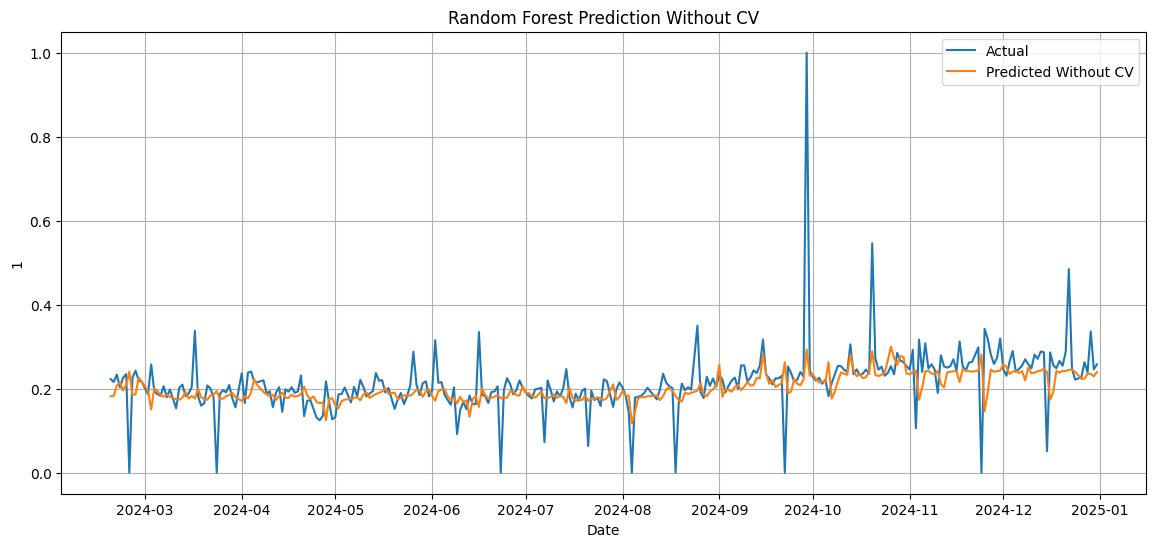

In [30]:
# Plotting without-CV prediction
plt.figure(figsize=(14, 6))

plt.plot(
    real_vs_prediction_no_cv_df["date"],
    real_vs_prediction_no_cv_df["real_col_1"],
    label="Actual"
)

plt.plot(
    real_vs_prediction_no_cv_df["date"],
    real_vs_prediction_no_cv_df["predicted_col_1"],
    label="Predicted Without CV"
)

plt.xlabel("Date")
plt.ylabel(target_col)
plt.title("Random Forest Prediction Without CV")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Comparing CV and without-CV results
comparison_results = pd.concat([
    summary_cv_results,
    no_cv_result
], ignore_index=True)

comparison_results = comparison_results.sort_values("MAE").reset_index(drop=True)

display(comparison_results)

,model,MAE,RMSE
0,Random Forest CV,0.035349,0.058593
1,Random Forest Without CV,0.036135,0.069438
2,Dummy Mean,0.039939,0.061041


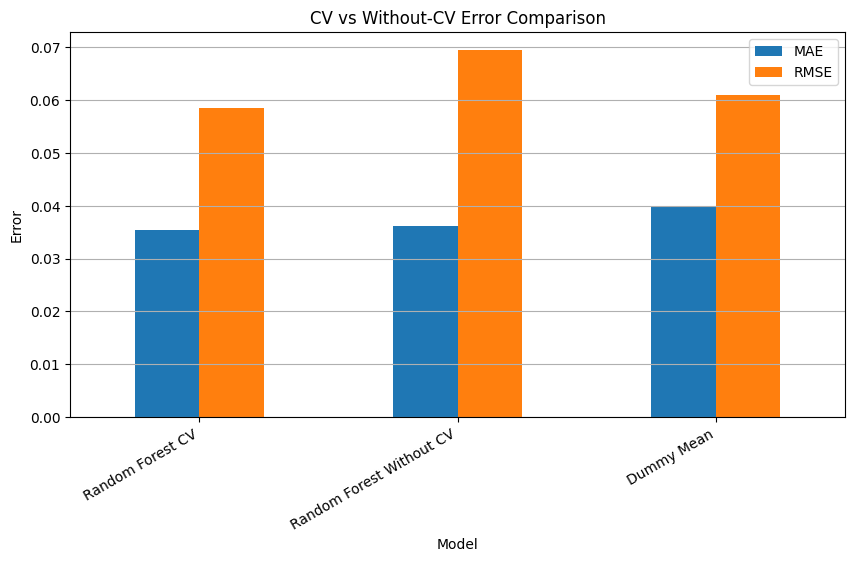

In [32]:
# Plotting model comparison
comparison_results.plot(
    x="model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("CV vs Without-CV Error Comparison")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()